# Módulo 3 - Visualização de Dados com Matplotlib e Seaborn

**Objetivo:** transformar tabelas em gráficos claros e interpretáveis.  
**Datasets usados:** `EquipeA_escola.csv` e `EquipeE_cidades.csv`.


---
## 1. Bibliotecas

O Matplotlib oferece controle mais direto sobre os gráficos. O Seaborn simplifica visualizações estatísticas e já vem com estilos mais agradáveis.


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

df_escola = pd.read_csv('../../datasets/escolhidos_ava_2/EquipeA_escola.csv')
df_cidades = pd.read_csv('../../datasets/escolhidos_ava_2/EquipeE_cidades.csv')


---
## 2. Visualização inicial com dataset pequeno

Começamos pelo dataset escolar porque ele facilita enxergar a relação entre os dados e o gráfico gerado.


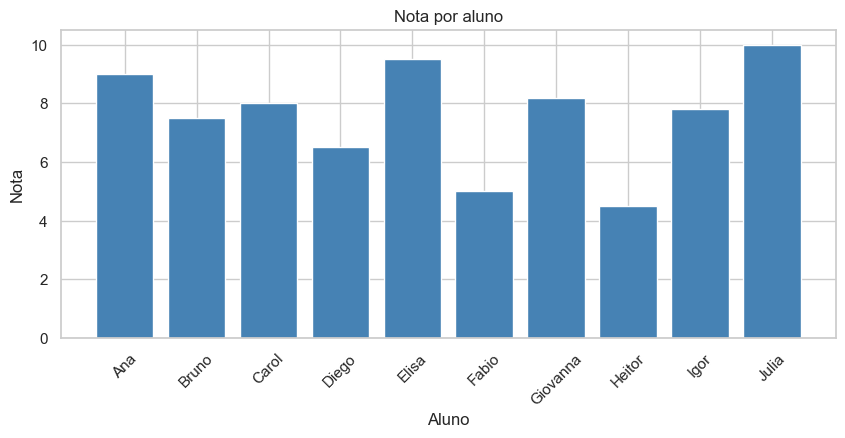

In [11]:
# Gráfico de barras com notas por aluno
plt.figure(figsize=(10, 4))
plt.bar(df_escola['nome'], df_escola['nota'], color='steelblue')
plt.title('Nota por aluno')
plt.xlabel('Aluno')
plt.ylabel('Nota')
plt.xticks(rotation=45)
plt.show()


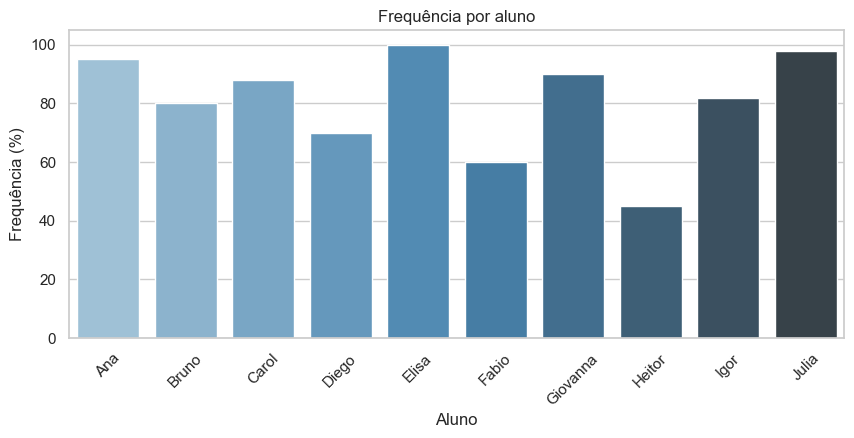

In [12]:
# Comparando frequência entre alunos com Seaborn
plt.figure(figsize=(10, 4))
sns.barplot(data=df_escola, x='nome', y='frequencia', hue='nome', legend=False, palette='Blues_d')
plt.title('Frequência por aluno')
plt.xlabel('Aluno')
plt.ylabel('Frequência (%)')
plt.xticks(rotation=45)
plt.show()


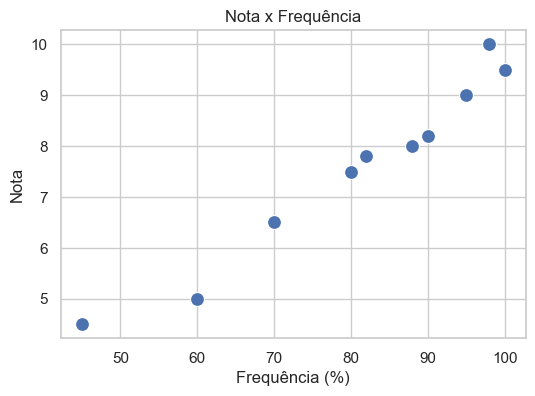

In [13]:
# Relação entre nota e frequência
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_escola, x='frequencia', y='nota', s=100)
plt.title('Nota x Frequência')
plt.xlabel('Frequência (%)')
plt.ylabel('Nota')
plt.show()


---
## 3. Visualização com dataset real

No dataset das cidades, precisamos selecionar um recorte para não gerar gráficos confusos demais.


In [14]:
colunas = ['CITY', 'STATE', 'ESTIMATED_POP', 'GDP_CAPITA', 'IDHM', 'HOTELS', 'BEDS', 'CAPITAL', 'LONG', 'LAT']
cidades = df_cidades[colunas].copy()
cidades.head()


,CITY,STATE,ESTIMATED_POP,GDP_CAPITA,IDHM,HOTELS,BEDS,CAPITAL,LONG,LAT
0,Abadia De Goiás,GO,8583,20665.0,0.708,0,0,0,-49.4405,-16.7588
1,Abadia Dos Dourados,MG,6972,25592.0,0.689,0,0,0,-47.3968,-18.4876
2,Abadiânia,GO,19614,15628.0,0.689,1,34,0,-48.7188,-16.1827
3,Abaetetuba,PA,156292,8222.0,0.628,0,0,0,-48.8844,-1.7235
4,Abaeté,MG,23223,18250.0,0.698,0,0,0,-45.4462,-19.1558


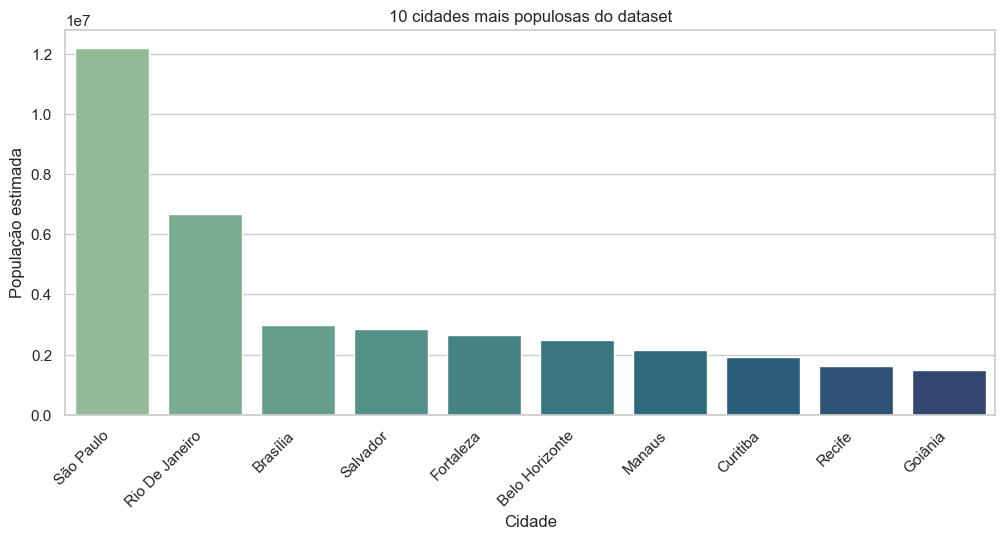

In [15]:
# Top 10 cidades por população estimada
top_pop = cidades.nlargest(10, 'ESTIMATED_POP')
plt.figure(figsize=(12, 5))
sns.barplot(data=top_pop, x='CITY', y='ESTIMATED_POP', hue='CITY', legend=False, palette='crest')
plt.title('10 cidades mais populosas do dataset')
plt.xlabel('Cidade')
plt.ylabel('População estimada')
plt.xticks(rotation=45, ha='right')
plt.show()


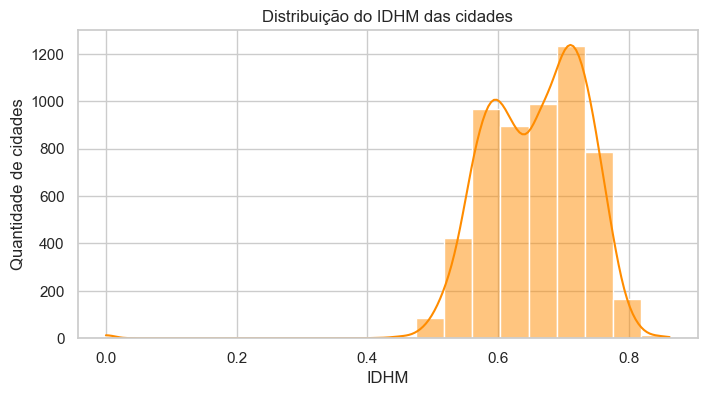

In [16]:
# Distribuição do IDHM
plt.figure(figsize=(8, 4))
sns.histplot(cidades['IDHM'], bins=20, kde=True, color='darkorange')
plt.title('Distribuição do IDHM das cidades')
plt.xlabel('IDHM')
plt.ylabel('Quantidade de cidades')
plt.show()


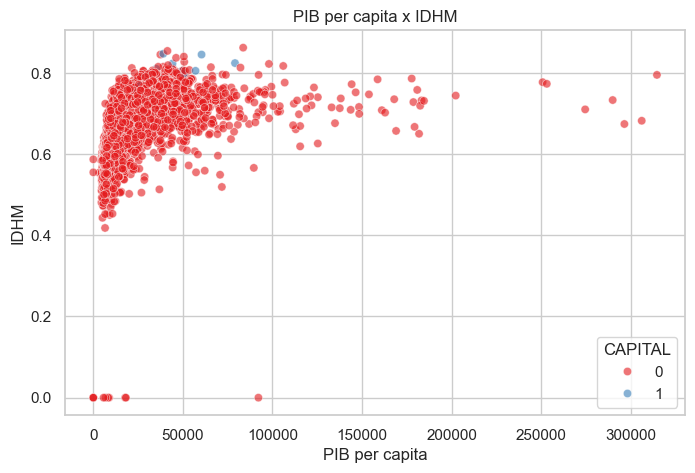

In [17]:
# Relação entre PIB per capita e IDHM
plt.figure(figsize=(8, 5))
sns.scatterplot(data=cidades, x='GDP_CAPITA', y='IDHM', alpha=0.6, hue='CAPITAL', palette='Set1')
plt.title('PIB per capita x IDHM')
plt.xlabel('PIB per capita')
plt.ylabel('IDHM')
plt.show()


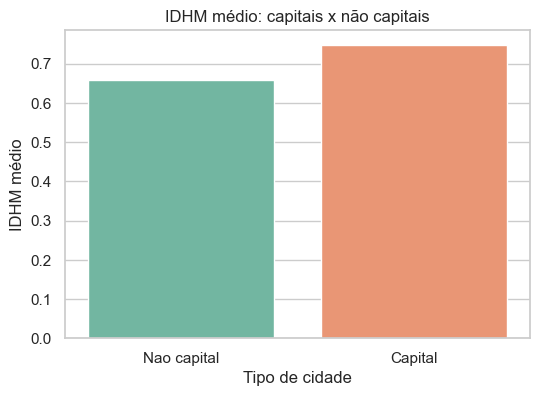

In [18]:
# Médias de IDHM por condição de capital
idhm_capital = cidades.groupby('CAPITAL', as_index=False)['IDHM'].mean()
idhm_capital['CAPITAL'] = idhm_capital['CAPITAL'].map({0: 'Nao capital', 1: 'Capital'})
plt.figure(figsize=(6, 4))
sns.barplot(data=idhm_capital, x='CAPITAL', y='IDHM', hue='CAPITAL', legend=False, palette='Set2')
plt.title('IDHM médio: capitais x não capitais')
plt.xlabel('Tipo de cidade')
plt.ylabel('IDHM médio')
plt.show()


---
## 4. Visualização em mapa simplificado

Mesmo sem bibliotecas geoespaciais extras, já é possível montar um **mapa de dispersão** usando longitude e latitude. Isso ajuda a perceber a distribuição espacial das cidades no território brasileiro.


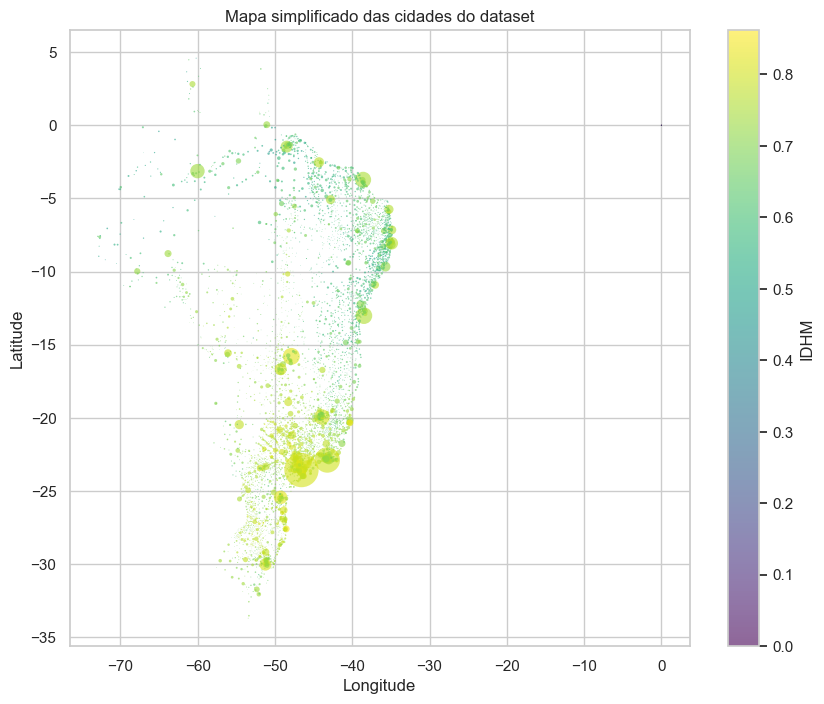

In [19]:
# Mapa simplificado: cada ponto representa uma cidade.
# A cor mostra o IDHM e o tamanho do ponto acompanha a população estimada.
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    cidades['LONG'],
    cidades['LAT'],
    c=cidades['IDHM'],
    s=cidades['ESTIMATED_POP'] / 20000,
    cmap='viridis',
    alpha=0.6,
    edgecolors='none'
)
plt.colorbar(scatter, label='IDHM')
plt.title('Mapa simplificado das cidades do dataset')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


Leitura possível: esse tipo de visualização permite observar a concentração espacial dos municípios e comparar, no mesmo plano, localização, porte populacional e nível de desenvolvimento humano.


---
## 5. Boas práticas

- escolha um tipo de gráfico coerente com a pergunta;
- use títulos objetivos;
- rotule eixos;
- evite excesso de categorias no mesmo gráfico;
- prefira recortes quando o dataset for muito grande.


---
## 6. Próximo passo

No notebook prático do módulo 3, vamos montar visualizações orientadas por perguntas de análise exploratória.
